# Adult Census Income Classification

Predicting whether an individual's annual income exceeds \$50K based on 1994 US Census demographic data.

Dataset: [Adult Census Income (UCI / Kaggle)](https://archive.ics.uci.edu/dataset/2/adult)

## 1. Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('adult.csv')
print(df.shape)
df.head()

(32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [3]:
df['income'].value_counts(normalize=True)

income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64

## 2. Data Cleaning & Preprocessing

The dataset uses `'?'` to represent missing values in categorical columns (`workclass`, `occupation`, `native.country`). These are replaced with NaN and dropped, since they make up a small fraction of rows.

In [4]:
df = df.replace('?', np.nan)
print('Missing values before dropping:')
print(df.isnull().sum()[df.isnull().sum() > 0])
df = df.dropna()
print('\nShape after dropping missing rows:', df.shape)

Missing values before dropping:
workclass         1836
occupation        1843
native.country     583
dtype: int64

Shape after dropping missing rows: (30162, 15)


In [5]:
df = df.drop_duplicates()
print('Shape after dropping duplicates:', df.shape)

Shape after dropping duplicates: (30139, 15)


## 3. Exploratory Data Analysis

/tmp/ipykernel_555/629883831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='income', data=df, ax=axes[1], palette='Set2')


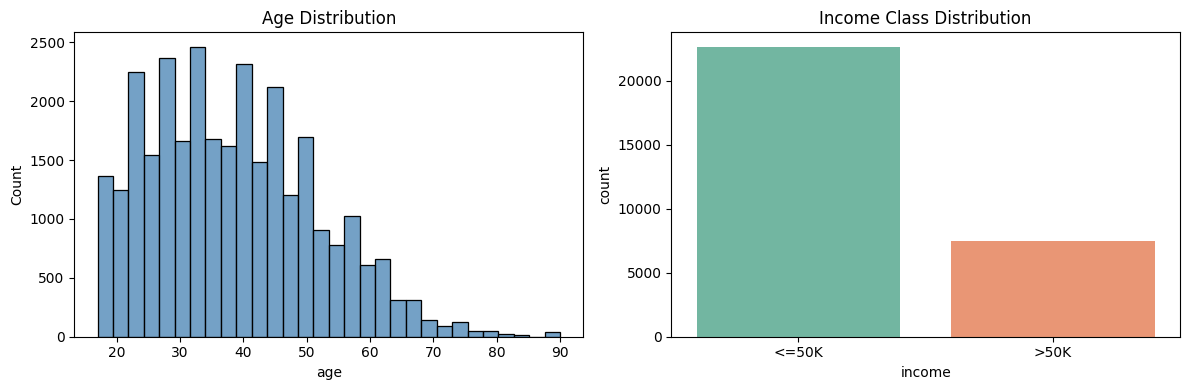

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['age'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')
sns.countplot(x='income', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Income Class Distribution')
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()

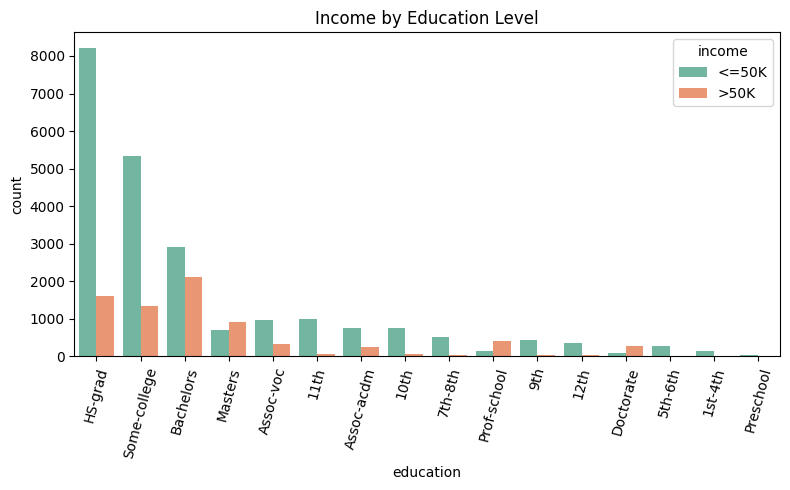

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x='education', hue='income', data=df,
              order=df['education'].value_counts().index, palette='Set2')
plt.xticks(rotation=75)
plt.title('Income by Education Level')
plt.tight_layout()
plt.savefig('education_vs_income.png', dpi=150)
plt.show()

## 4. Feature Engineering

- Encode the target variable (`income`) as 0/1.
- Label-encode ordinal-ish / high-cardinality categoricals, one-hot encode the rest.
- Drop `education` (redundant with `education.num`) and `fnlwgt` (a census sampling weight, not predictive of individual income).

In [8]:
data = df.copy()
data['income'] = data['income'].map({'<=50K': 0, '>50K': 1})
data = data.drop(columns=['education', 'fnlwgt'])

categorical_cols = ['workclass', 'marital.status', 'occupation', 'relationship',
                    'race', 'sex', 'native.country']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
print(data.shape)
data.head()

(30139, 81)


,age,education.num,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
1,82,9,0,4356,18,0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,54,4,0,3900,40,0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,41,10,0,3900,40,0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
5,34,9,0,3770,45,0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
6,38,6,0,3770,40,0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.drop('income', axis=1)
y = data['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
num_cols = ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Train shape: (24111, 80)  Test shape: (6028, 80)


## 5. Model Training

We train and compare two classifiers: Logistic Regression (a strong linear baseline) and Random Forest (a non-linear ensemble).

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print('Models trained.')

Models trained.


## 6. Model Evaluation

In [11]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)

results = {}
for name, model in [('Logistic Regression', log_reg), ('Random Forest', rf)]:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.852356,0.745382,0.618254,0.675892,0.908590
Random Forest,0.862641,0.816557,0.578281,0.677067,0.918561


In [12]:
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=['<=50K', '>50K']))

              precision    recall  f1-score   support

       <=50K       0.87      0.96      0.91      4527
        >50K       0.82      0.58      0.68      1501

    accuracy                           0.86      6028
   macro avg       0.84      0.77      0.79      6028
weighted avg       0.86      0.86      0.85      6028



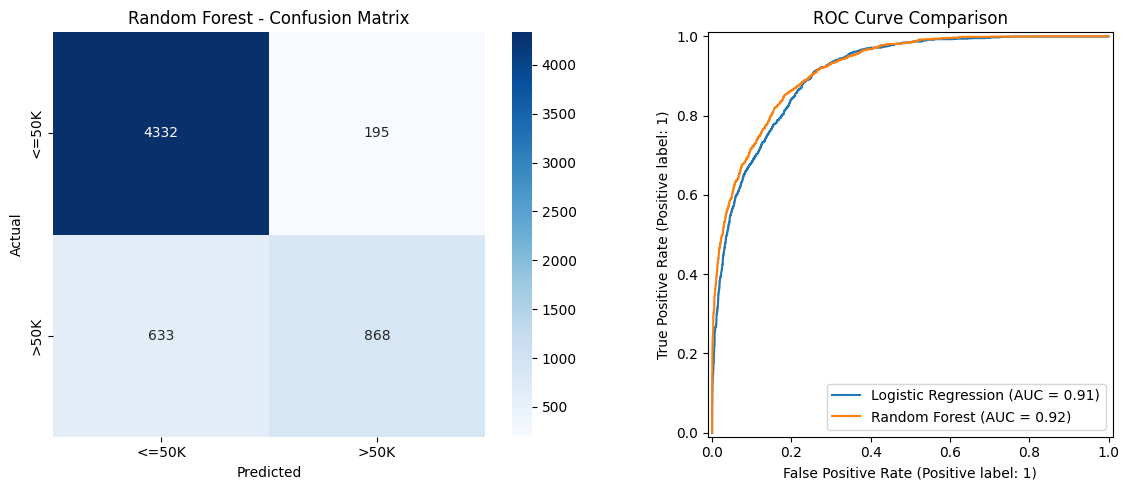

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'], ax=axes[0])
axes[0].set_title('Random Forest - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

RocCurveDisplay.from_estimator(log_reg, X_test, y_test, ax=axes[1], name='Logistic Regression')
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=axes[1], name='Random Forest')
axes[1].set_title('ROC Curve Comparison')

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150)
plt.show()

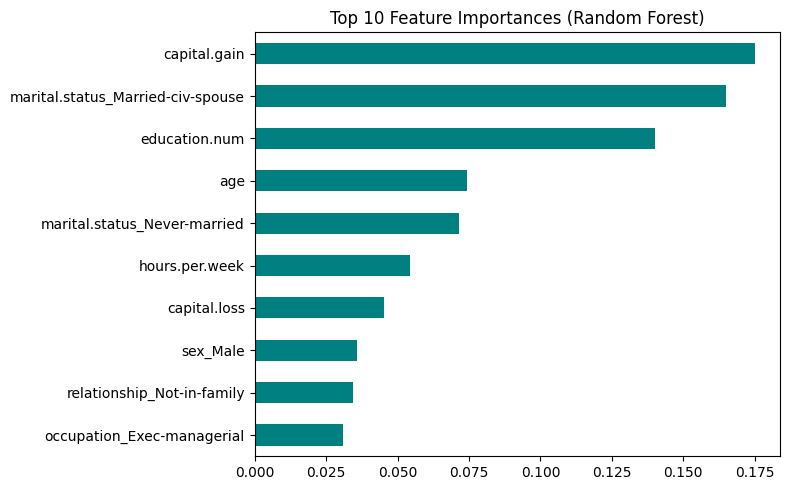

In [14]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_features.sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

### Observations

1. The Random Forest model outperforms Logistic Regression across all metrics, particularly ROC-AUC, indicating it captures non-linear interactions between features that the linear model misses.
2. `marital.status`, `capital.gain`, `age`, and `education.num` consistently rank as the most important predictors of high income — married individuals and those with capital gains or higher education are far more likely to earn >$50K.
3. The dataset is imbalanced (~75% earn <=50K), so precision/recall/F1 and ROC-AUC are more informative than raw accuracy alone.

## 7. Conclusion

This project classified individuals' income level (`<=50K` vs `>50K`) using 1994 US Census demographic data. After cleaning missing values encoded as `'?'` and engineering categorical features, both Logistic Regression and Random Forest models were trained and compared. The Random Forest model achieved the stronger overall performance, with marital status, capital gains, age, and education level emerging as the most influential predictors of higher income. These results reflect intuitive real-world patterns: higher education and more work experience (age) correlate with higher earnings, and capital gains often indicate existing wealth. A key limitation is class imbalance in the target variable, which can bias models toward the majority class (`<=50K`) unless addressed through techniques like class weighting, oversampling (e.g. SMOTE), or threshold tuning — an avenue for further improvement.